# 데이터 불러오기

In [1]:
import kagglehub # 캐글 데이터 불러오기

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


In [2]:
import torch
import os

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
train_dir = os.path.join(path, "chest_xray", "train")
val_dir = os.path.join(path, "chest_xray", "val")
test_dir = os.path.join(path, "chest_xray", "test")

In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

transforms = v2.Compose(
    [
        v2.Resize((224, 224)),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
    ]
)

# 데이터셋 로드
train_dataset = datasets.ImageFolder(train_dir, transform=transforms)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 클래스 확인
class_names = train_dataset.classes
print("Class names:", class_names)

Class names: ['NORMAL', 'PNEUMONIA']


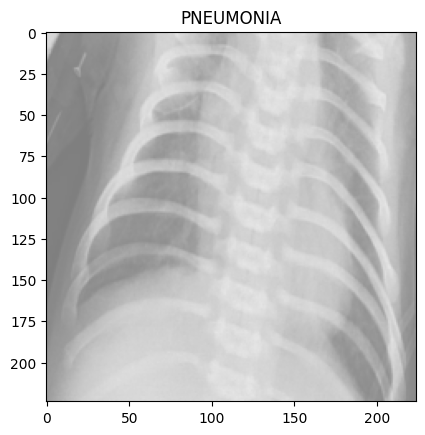

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 로더에서 배치 가져오기 (train)
images, labels = next(iter(train_loader))

# 이미지를 디스플레이
def imshow(img, title):
    img = img / 2 + 0.5  # 정규화된 값을 화면 표시용 0~1 범위로 복원
    '''밑에 셀에서 정규화 된걸 가지고 위에서는 음수가 없도록 해서 데이터를 imshow로 이미지화'''
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.show()

# 첫 번째 배치의 첫 번째 이미지 시각화
imshow(images[0], title=class_names[labels[0]])

In [6]:
# 데이터 전처리 정의 
# 이미 분리된 학습·검증·테스트 데이터의 전처리 방법을 정의한다.
# 학습 데이터에만 랜덤 크롭과 회전으로 데이터 증강을 적용한다.
# 모든 데이터에 텐서 변환과 정규화를 적용한다.

data_transforms = { # 데이터 용도별 전처리 방법을 담는 딕셔너리
    'train': v2.Compose([ # 이미지 전처리 방법을 불러옴 위에서 improt함
        v2.Resize((224, 224)),                # 이미지 크기 조정
        v2.RandomCrop((200, 200)),           # 랜덤 크롭 (200x200)
        v2.RandomRotation(20),              # 랜덤 회전 (-20도 ~ 20도)
        v2.ToTensor(),                       # 텐서로 변환
        v2.Normalize([0.5], [0.5])           # 정규화
    ]),
    'val': v2.Compose([
        v2.Resize((224, 224)),               # 이미지 크기 조정
        v2.ToTensor(),                       # 텐서로 변환
        v2.Normalize([0.5], [0.5])           # 정규화
    ]),
    'test': v2.Compose([
        v2.Resize((224, 224)),               # 이미지 크기 조정
        v2.ToTensor(),                       # 텐서로 변환
        v2.Normalize([0.5], [0.5])           # 정규화
    ])
}

'''위에 경고 메세지는 ToTensor는 없어질꺼니깐 v2.ToImage()로 바꿔달라는 소리고 내꺼 쓸때는 v2.ToImage()쓰기'''

/usr/local/lib/python3.13/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


'위에 경고 메세지는 ToTensor는 없어질꺼니깐 v2.ToImage()로 바꿔달라는 소리고 내꺼 쓸때는 v2.ToImage()쓰기'

In [7]:
from torchvision import datasets
from torch.utils.data import DataLoader

# 데이터셋 로드
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # GPU가 처리하기 좋아하는 32
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
'''validation장수가 적어보인다. 학습데이터에서 좀 더 가져와도 되지 않을까?'''

Number of training samples: 5216
Number of validation samples: 16
Number of test samples: 624


'validation장수가 적어보인다. 학습데이터에서 좀 더 가져와도 되지 않을까?'

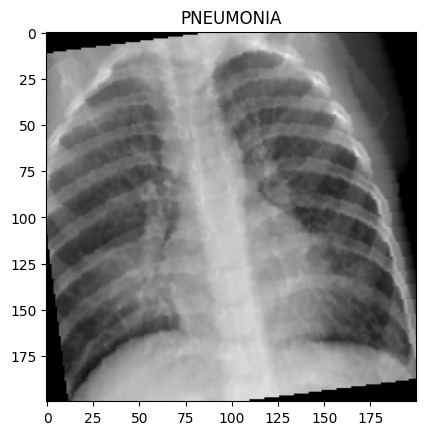

In [8]:
# 데이터 로더에서 배치 가져오기 (train)
images, labels = next(iter(train_loader))

# 이미지를 디스플레이
def imshow(img, title):
    img = img / 2 + 0.5  # 정규화 복원
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.show()

# 첫 번째 배치의 첫 번째 이미지 시각화
imshow(images[0], title=class_names[labels[0]])

# Custom CNN 모델 생성

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F #신경망에서 쓰는 연산을 함수 형태로 모아둔 모듈

# Custom CNN 모델 정의
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  # 입력 채널: 3, 출력 채널: 32
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                  # MaxPooling
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1) # Conv2D
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))                       # Adaptive Pooling (7x7)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)                             # Fully Connected Layer
        self.fc2 = nn.Linear(128, num_classes)                            # Output Layer

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # Conv1 + Pooling
        x = self.pool(F.relu(self.conv2(x)))  # Conv2 + Pooling
        x = self.avgpool(x)                   # Adaptive Pooling
        x = torch.flatten(x, 1)               # Flattening
        x = F.relu(self.fc1(x))               # Fully Connected Layer 1
        x = self.fc2(x)                       # Output Layer
        return x

# 클래스 수 설정 (NORMAL, PNEUMONIA)
num_classes = len(class_names)

In [ ]:
import torch.optim as optim # 옵티마이저 모듈 불러오기

model = CustomCNN(num_classes).to(device) # 모델 생성 후 실행장치로 이동
loss_fn = nn.CrossEntropyLoss() # 교차엔트로피 손실 함수 준비
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam 옵티마이저 준비

# 모델 학습 및 평가

In [11]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    step = 0
    for epoch in range(num_epochs):
        model.train()  # 모델을 학습 모드로 설정
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            # 데이터를 GPU/CPU로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 이전 그래디언트 초기화
            optimizer.zero_grad()

            # Forward Pass
            outputs = model(inputs)

            # 손실 계산
            loss = criterion(outputs, labels)
            loss.backward()  # Backward Pass

            # 가중치 업데이트
            optimizer.step()

            running_loss += loss.item()

            # 정확도 계산
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            step += 1

        # 학습 손실 및 정확도 출력
        avg_train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # 검증 단계 수행
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

In [12]:
def evaluate(model, dataloader, loss_fn):
    model.eval()

    losses = []  # 손실값을 저장할 리스트
    correct = 0  # 올바르게 예측한 샘플 수
    total = 0    # 전체 샘플 수

    with torch.no_grad():
        for inputs, labels in dataloader:
            # 데이터를 GPU 또는 CPU로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델의 예측값 계산
            outputs = model(inputs)

            # 손실값 계산
            loss = loss_fn(outputs, labels)
            losses.append(loss.item())

            # 예측값 가져오기
            pred_labels = torch.argmax(outputs, dim=1)  # [배치 크기]
            correct += (pred_labels == labels).sum().item()
            total += labels.size(0)

    # 평균 손실값과 정확도 계산
    avg_loss = sum(losses) / len(losses)
    accuracy = correct / total

    return avg_loss, accuracy

In [13]:
train(model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)

Epoch 1/10, Train Loss: 0.3950, Train Acc: 0.8344, Val Loss: 1.9053, Val Acc: 0.5625
Epoch 2/10, Train Loss: 0.2416, Train Acc: 0.9064, Val Loss: 0.8225, Val Acc: 0.6250
Epoch 3/10, Train Loss: 0.1748, Train Acc: 0.9310, Val Loss: 0.8753, Val Acc: 0.6250
Epoch 4/10, Train Loss: 0.1563, Train Acc: 0.9410, Val Loss: 0.5307, Val Acc: 0.7500
Epoch 5/10, Train Loss: 0.1426, Train Acc: 0.9440, Val Loss: 0.6944, Val Acc: 0.7500
Epoch 6/10, Train Loss: 0.1469, Train Acc: 0.9431, Val Loss: 0.9565, Val Acc: 0.6875
Epoch 7/10, Train Loss: 0.1314, Train Acc: 0.9515, Val Loss: 0.6554, Val Acc: 0.6875
Epoch 8/10, Train Loss: 0.1170, Train Acc: 0.9559, Val Loss: 0.6213, Val Acc: 0.7500
Epoch 9/10, Train Loss: 0.1186, Train Acc: 0.9563, Val Loss: 1.1381, Val Acc: 0.5625
Epoch 10/10, Train Loss: 0.1144, Train Acc: 0.9561, Val Loss: 0.9294, Val Acc: 0.5625


In [ ]:
# 테스트 정확도(Accuracy)
test_loss, test_acc = evaluate(model, test_loader, loss_fn)

test_acc # 정확도
test_loss # 손실



# total = len(test_loader.dataset)
# correct = round(test_acc * total)

# print(f"테스트 정확도: {test_acc:.2%}")
# print(f"전체 {total}장 중 {correct}장 정답, {total - correct}장 오답")

0.46566717193927615

# Transfer Learning

In [15]:
import torchvision.models as models

# Pretrained ResNet 모델 로드
pretrained_model = models.resnet18(pretrained=True)

# Feature Extractor 동결 (파라미터 업데이트 불가)
for param in pretrained_model.parameters():
    param.requires_grad = False

# Classifier 교체 (기존 Fully Connected Layer를 새로운 Classifier로 교체)
num_features = pretrained_model.fc.in_features  # 기존 Fully Connected Layer 입력 크기
pretrained_model.fc = nn.Linear(num_features, num_classes)  # 새 출력층 생성
pretrained_model = pretrained_model.to(device)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


In [18]:
# cpu → CPU에 있음
# cuda:0 → 첫 번째 GPU에 있음
# cuda:1 → 두 번째 GPU에 있음

print(pretrained_model.fc.weight.device)
'''이 코드는 사전 학습 모델의 마지막 출력층(fc) 가중치가 어느 장치에 있는지 확인'''

cuda:0


'이 코드는 사전 학습 모델의 마지막 출력층(fc) 가중치가 어느 장치에 있는지 확인'

In [17]:
# 손실 함수와 Optimizer 설정
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 실행
train(pretrained_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)

# 테스트 실행
evaluate(pretrained_model, test_loader, loss_fn)

Epoch 1/10, Train Loss: 0.6343, Train Acc: 0.6791, Val Loss: 0.8689, Val Acc: 0.4375
Epoch 2/10, Train Loss: 0.6303, Train Acc: 0.6839, Val Loss: 0.8688, Val Acc: 0.4375
Epoch 3/10, Train Loss: 0.6336, Train Acc: 0.6885, Val Loss: 0.8663, Val Acc: 0.4375
Epoch 4/10, Train Loss: 0.6360, Train Acc: 0.6768, Val Loss: 0.8626, Val Acc: 0.4375
Epoch 5/10, Train Loss: 0.6307, Train Acc: 0.6764, Val Loss: 0.8614, Val Acc: 0.4375
Epoch 6/10, Train Loss: 0.6335, Train Acc: 0.6770, Val Loss: 0.8601, Val Acc: 0.4375
Epoch 7/10, Train Loss: 0.6350, Train Acc: 0.6800, Val Loss: 0.8644, Val Acc: 0.4375
Epoch 8/10, Train Loss: 0.6313, Train Acc: 0.6754, Val Loss: 0.8589, Val Acc: 0.4375
Epoch 9/10, Train Loss: 0.6302, Train Acc: 0.6823, Val Loss: 0.8670, Val Acc: 0.4375
Epoch 10/10, Train Loss: 0.6318, Train Acc: 0.6787, Val Loss: 0.8614, Val Acc: 0.4375


(0.7136113807559014, 0.5705128205128205)

# Transfer Learning (Partial Fine-Tuning)

In [19]:
# Pretrained ResNet 모델 로드
pretrained_model = models.resnet18(pretrained=True)

# Feature Extractor의 초기 층 동결
for name, param in pretrained_model.named_parameters():
    if "layer4" in name or "fc" in name:  # ResNet의 마지막 블록(layer4)와 Fully Connected Layer만 학습 가능
        param.requires_grad = True
    else:
        param.requires_grad = False

# Classifier 교체
num_features = pretrained_model.fc.in_features  # 기존 Fully Connected Layer 입력 크기
pretrained_model.fc = nn.Linear(num_features, num_classes)  # 새 출력층 생성

print("Trainable parameters:")
for name, param in pretrained_model.named_parameters():
    if param.requires_grad:
        print(name)

pretrained_model = pretrained_model.to(device)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Trainable parameters:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [20]:
# 손실 함수와 Optimizer 설정
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 실행
train(pretrained_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)

# 테스트 실행
evaluate(pretrained_model, test_loader, loss_fn)

Epoch 1/10, Train Loss: 0.8488, Train Acc: 0.3401, Val Loss: 0.6663, Val Acc: 0.6875
Epoch 2/10, Train Loss: 0.8493, Train Acc: 0.3430, Val Loss: 0.6627, Val Acc: 0.6875
Epoch 3/10, Train Loss: 0.8515, Train Acc: 0.3403, Val Loss: 0.6732, Val Acc: 0.6875
Epoch 4/10, Train Loss: 0.8440, Train Acc: 0.3434, Val Loss: 0.6761, Val Acc: 0.6250
Epoch 5/10, Train Loss: 0.8480, Train Acc: 0.3405, Val Loss: 0.6634, Val Acc: 0.6875
Epoch 6/10, Train Loss: 0.8473, Train Acc: 0.3430, Val Loss: 0.6679, Val Acc: 0.6875
Epoch 7/10, Train Loss: 0.8518, Train Acc: 0.3453, Val Loss: 0.6693, Val Acc: 0.6875
Epoch 8/10, Train Loss: 0.8505, Train Acc: 0.3347, Val Loss: 0.6754, Val Acc: 0.6875
Epoch 9/10, Train Loss: 0.8464, Train Acc: 0.3436, Val Loss: 0.6786, Val Acc: 0.6875
Epoch 10/10, Train Loss: 0.8509, Train Acc: 0.3380, Val Loss: 0.6732, Val Acc: 0.6875


(0.8083668887615204, 0.47435897435897434)

# Transfer Learning (Full Fine-Tuning)

In [21]:
# Pretrained ResNet 모델 로드
pretrained_model = models.resnet18(pretrained=True)

# 모든 층 학습 가능하도록 설정
for param in pretrained_model.parameters():
    param.requires_grad = True

# Classifier 교체
num_features = pretrained_model.fc.in_features  # 기존 Fully Connected Layer 입력 크기
pretrained_model.fc = nn.Linear(num_features, num_classes)  # 새 출력층 생성
pretrained_model = pretrained_model.to(device)

In [22]:
# 손실 함수와 Optimizer 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_model.parameters(), lr=0.00001)  # Full Fine-Tuning에서는 더 낮은 학습률

In [23]:
# 학습 실행
train(pretrained_model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10)

# 테스트 실행
evaluate(pretrained_model, test_loader, loss_fn)

Epoch 1/10, Train Loss: 0.3106, Train Acc: 0.8723, Val Loss: 0.4323, Val Acc: 0.7500
Epoch 2/10, Train Loss: 0.1143, Train Acc: 0.9620, Val Loss: 0.3427, Val Acc: 0.7500
Epoch 3/10, Train Loss: 0.0939, Train Acc: 0.9689, Val Loss: 0.2113, Val Acc: 0.8750
Epoch 4/10, Train Loss: 0.0759, Train Acc: 0.9718, Val Loss: 0.3118, Val Acc: 0.7500
Epoch 5/10, Train Loss: 0.0729, Train Acc: 0.9749, Val Loss: 0.4460, Val Acc: 0.7500
Epoch 6/10, Train Loss: 0.0613, Train Acc: 0.9795, Val Loss: 0.1833, Val Acc: 0.9375
Epoch 7/10, Train Loss: 0.0612, Train Acc: 0.9797, Val Loss: 0.2720, Val Acc: 0.8125
Epoch 8/10, Train Loss: 0.0534, Train Acc: 0.9810, Val Loss: 0.1635, Val Acc: 0.9375
Epoch 9/10, Train Loss: 0.0463, Train Acc: 0.9833, Val Loss: 0.1228, Val Acc: 0.9375
Epoch 10/10, Train Loss: 0.0439, Train Acc: 0.9850, Val Loss: 0.1264, Val Acc: 0.9375


(0.2912776992539875, 0.9038461538461539)